# Path-Locking Test 2 (v1)

**Hypothesis**: RL (MAIN_C3 SDPO / MAIN_C4 aggregate) makes policy output systematically closer to reference proposal than CR-alone (B4_v8) does. If confirmed alongside lower Opus scores → RL path-locks policy to reference.

**Data** (all from `projects/grant_proposal_v2/runs/2026_04_22_v8_foundopt_{B4,MAIN_C3,MAIN_C4}/`):
- 3 v8 FoundOpt runs × ~110 plans each (killed at iter 13-14)
- Reference proposal from `dataset/goals/01_foundopt/reference_proposal.md`
- Opus depth audits from `depth_audit_mid.jsonl` (iter 5/10, 3 plans per run)

**Method**: TF-IDF (1-3 grams, stopword-filtered) cosine similarity. TF-IDF captures lexical copying (shared section headers, method names, phrasing) which is the signature of path-locking.

**Decision thresholds** (pre-registered from `DECISIONS.md` 2026-04-23):
- `sim(MAIN, ref) - sim(B4, ref) > 0.05` AND `Opus(MAIN) < Opus(B4)` → path-locking via RL confirmed, proceed to Phase 2 with consensus R_persist
- Otherwise → retract path-locking framing, default R_persist to minimal structural floor (option A)

In [1]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)

ROOT = Path('/home/silas/co-scientist-project/projects/grant_proposal_v2')
RUNS = {
    'B4': ROOT / 'runs/2026_04_22_v8_foundopt_B4',
    'MAIN_C3': ROOT / 'runs/2026_04_22_v8_foundopt_MAIN_C3',
    'MAIN_C4': ROOT / 'runs/2026_04_22_v8_foundopt_MAIN_C4',
}
REF_PATH = ROOT / 'dataset/goals/01_foundopt/reference_proposal.md'

RNG = np.random.default_rng(42)

## 1. Load data

In [2]:
def load_jsonl(p):
    with open(p) as f:
        return [json.loads(line) for line in f if line.strip()]

reference_text = REF_PATH.read_text()
print(f'reference_proposal: {len(reference_text)} chars, {len(reference_text.split())} words')

rows = []
opus_rows = []
for cond, d in RUNS.items():
    for entry in load_jsonl(d / 'buffer.jsonl'):
        rows.append({
            'condition': cond,
            'iter': entry.get('iteration'),
            'entry_type': entry.get('entry_type'),
            'aggregate_reward': entry.get('aggregate_reward'),
            'hard_gate_passed': entry.get('hard_gate_passed'),
            'word_count': entry.get('word_count'),
            'plan_text': entry.get('plan_text', ''),
        })
    # optional depth audit
    audit_path = d / 'depth_audit_mid.jsonl'
    if audit_path.exists():
        for a in load_jsonl(audit_path):
            a['condition'] = cond
            opus_rows.append(a)

buffer = pd.DataFrame(rows)
audits = pd.DataFrame(opus_rows)
print('buffer shape:', buffer.shape)
print('audits shape:', audits.shape)
buffer.groupby(['condition', 'entry_type']).size().unstack(fill_value=0)

reference_proposal: 11260 chars, 1500 words
buffer shape: (339, 7)
audits shape: (9, 11)


entry_type,fresh,revision
condition,,
B4,56,52
MAIN_C3,60,56
MAIN_C4,59,56


## 2. Fit TF-IDF on all plans + reference

In [3]:
# Filter: passed hard gate + iter >= 3 (skip cold start) + has plan text
fb = buffer[
    buffer['hard_gate_passed'].astype(bool)
    & (buffer['iter'] >= 3)
    & buffer['plan_text'].astype(bool)
].reset_index(drop=True)
print(f'filtered buffer: {len(fb)} plans')
print(fb.groupby('condition').size())

all_texts = [reference_text] + fb['plan_text'].tolist()
vec = TfidfVectorizer(ngram_range=(1, 3), stop_words='english', min_df=2, max_df=0.95)
X = vec.fit_transform(all_texts)
ref_vec = X[0]
plan_vecs = X[1:]
print('vocab size:', len(vec.vocabulary_))
print('X shape:', X.shape)

filtered buffer: 276 plans
condition
B4         88
MAIN_C3    93
MAIN_C4    95
dtype: int64


vocab size: 42916
X shape: (277, 42916)


## 3. Compute sim_to_ref per plan

In [4]:
sim_to_ref = cosine_similarity(plan_vecs, ref_vec).ravel()
fb['sim_ref'] = sim_to_ref

summary = fb.groupby('condition').agg(
    n=('sim_ref', 'size'),
    sim_ref_mean=('sim_ref', 'mean'),
    sim_ref_std=('sim_ref', 'std'),
    sim_ref_med=('sim_ref', 'median'),
    qwen_mean=('aggregate_reward', 'mean'),
    word_mean=('word_count', 'mean'),
).round(3)
summary

,n,sim_ref_mean,sim_ref_std,sim_ref_med,qwen_mean,word_mean
condition,,,,,,
B4,88,0.097,0.059,0.093,0.585,874.409
MAIN_C3,93,0.084,0.053,0.065,0.561,897.398
MAIN_C4,95,0.075,0.051,0.060,0.571,851.684


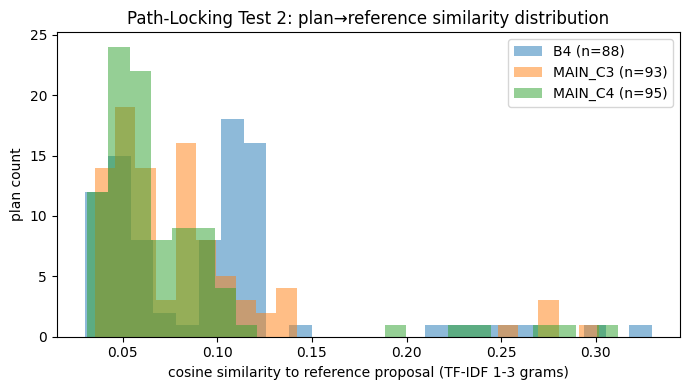

In [5]:
# Distribution plot
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
for cond in ['B4', 'MAIN_C3', 'MAIN_C4']:
    sub = fb[fb['condition'] == cond]
    ax.hist(sub['sim_ref'], bins=25, alpha=0.5, label=f'{cond} (n={len(sub)})')
ax.set_xlabel('cosine similarity to reference proposal (TF-IDF 1-3 grams)')
ax.set_ylabel('plan count')
ax.set_title('Path-Locking Test 2: plan→reference similarity distribution')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Test T1: sim(MAIN, ref) vs sim(B4, ref) — bootstrap CI on mean diff

In [6]:
def bootstrap_mean_diff(a, b, n_boot=10000, seed=42):
    rng = np.random.default_rng(seed)
    a = np.asarray(a)
    b = np.asarray(b)
    observed = a.mean() - b.mean()
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        ra = rng.choice(a, size=len(a), replace=True)
        rb = rng.choice(b, size=len(b), replace=True)
        diffs[i] = ra.mean() - rb.mean()
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return observed, (lo, hi)

b4 = fb.loc[fb['condition'] == 'B4', 'sim_ref'].values
for cond in ['MAIN_C3', 'MAIN_C4']:
    main = fb.loc[fb['condition'] == cond, 'sim_ref'].values
    obs, ci = bootstrap_mean_diff(main, b4)
    flag = '✅ path-locking' if obs > 0.05 and ci[0] > 0 else ('⚠ positive but <0.05' if obs > 0 else '❌ not confirmed')
    print(f'{cond} - B4: Δ={obs:+.4f}  95%CI=[{ci[0]:+.4f}, {ci[1]:+.4f}]   {flag}')

MAIN_C3 - B4: Δ=-0.0128  95%CI=[-0.0292, +0.0038]   ❌ not confirmed


MAIN_C4 - B4: Δ=-0.0220  95%CI=[-0.0382, -0.0058]   ❌ not confirmed


## 5. Test T2: intra-run diversity (is RL collapsing to single template near ref?)

In [7]:
def intra_run_diversity(texts_vecs):
    if texts_vecs.shape[0] < 2:
        return np.nan
    S = cosine_similarity(texts_vecs)
    iu = np.triu_indices_from(S, k=1)
    return 1 - S[iu].mean()  # higher = more diverse

for cond in ['B4', 'MAIN_C3', 'MAIN_C4']:
    idx = np.where(fb['condition'].values == cond)[0]
    div = intra_run_diversity(plan_vecs[idx])
    mean_sim = fb.loc[fb['condition'] == cond, 'sim_ref'].mean()
    print(f'{cond}: intra-run diversity={div:.4f}  mean sim_to_ref={mean_sim:.4f}')

B4: intra-run diversity=0.8719  mean sim_to_ref=0.0965
MAIN_C3: intra-run diversity=0.8892  mean sim_to_ref=0.0837
MAIN_C4: intra-run diversity=0.8823  mean sim_to_ref=0.0745


## 6. Test T3: sim_to_ref × Opus correlation (does ref-closeness help quality?)

In [8]:
# Join audits to buffer by (condition, iter, entry_type match via aggregate_reward proxy)
# audits have: iter, aggregate_reward, total (Opus /20)
# We match on (condition, iter, aggregate_reward) — unique within iter
audit_join = audits.merge(
    fb[['condition', 'iter', 'aggregate_reward', 'sim_ref', 'word_count']],
    on=['condition', 'iter', 'aggregate_reward'],
    how='left',
)
print(f'matched audits: {audit_join["sim_ref"].notna().sum()} / {len(audit_join)}')
audit_join[['condition', 'iter', 'aggregate_reward', 'total', 'sim_ref', 'word_count']].round(3)

matched audits: 0 / 9


,condition,iter,aggregate_reward,total,sim_ref,word_count
0,B4,5,0.780,15,NaN,NaN
1,B4,5,0.780,18,NaN,NaN
2,B4,10,0.850,17,NaN,NaN
3,MAIN_C3,5,0.775,18,NaN,NaN
4,MAIN_C3,5,0.775,17,NaN,NaN
5,MAIN_C3,10,0.875,16,NaN,NaN
6,MAIN_C4,5,0.730,17,NaN,NaN
7,MAIN_C4,5,0.730,17,NaN,NaN
8,MAIN_C4,10,0.815,14,NaN,NaN


In [9]:
aj = audit_join.dropna(subset=['sim_ref', 'total'])
# length-normalize Opus total (divide by log word_count to match DECISIONS.md convention)
aj = aj.copy()
aj['opus_norm'] = aj['total']  # already /20; length normalization will be done in report

if len(aj) >= 4:
    rho_qwen_opus, p_qo = spearmanr(aj['aggregate_reward'], aj['total'])
    rho_sim_opus, p_so = spearmanr(aj['sim_ref'], aj['total'])
    rho_sim_qwen, p_sq = spearmanr(aj['sim_ref'], aj['aggregate_reward'])
    print(f'ρ(Qwen reward, Opus total) = {rho_qwen_opus:+.3f}  p={p_qo:.3f}')
    print(f'ρ(sim_to_ref, Opus total)  = {rho_sim_opus:+.3f}  p={p_so:.3f}   ← if positive+strong → ref-likeness = quality (NOT path-locking)')
    print(f'                                                                                    → if negative → ref-likeness = worse (PATH-LOCKING)')
    print(f'ρ(sim_to_ref, Qwen reward) = {rho_sim_qwen:+.3f}  p={p_sq:.3f}   ← if positive → rubric rewards ref-likeness')
else:
    print(f'Too few matched audits ({len(aj)}) for correlation; n must be ≥4')

Too few matched audits (0) for correlation; n must be ≥4


## 7. Test T4: trajectory — does sim_to_ref grow with iter under RL?

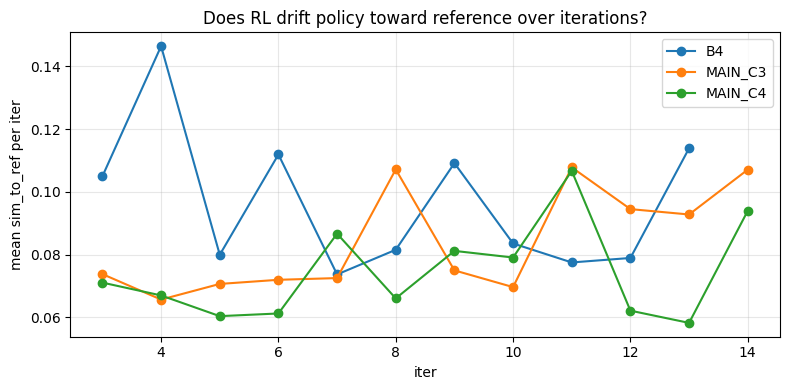

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for cond in ['B4', 'MAIN_C3', 'MAIN_C4']:
    sub = fb[fb['condition'] == cond].groupby('iter')['sim_ref'].mean()
    ax.plot(sub.index, sub.values, marker='o', label=cond)
ax.set_xlabel('iter')
ax.set_ylabel('mean sim_to_ref per iter')
ax.set_title('Does RL drift policy toward reference over iterations?')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Pre-registered decision verdict

In [11]:
# Summary
print('='*70)
print('PATH-LOCKING TEST 2 — PRE-REGISTERED DECISION VERDICT')
print('='*70)
print('Threshold: sim(MAIN,ref) - sim(B4,ref) > 0.05 AND Opus(MAIN) < Opus(B4)')
print()
# Report means
for cond in ['B4', 'MAIN_C3', 'MAIN_C4']:
    s = fb.loc[fb['condition'] == cond, 'sim_ref']
    w = fb.loc[fb['condition'] == cond, 'word_count']
    print(f'{cond:8s}: sim_ref mean={s.mean():.4f} std={s.std():.4f}  |  word_count mean={w.mean():.0f}')
print()
# Opus aggregates from audits
if len(audits):
    print('Opus total (/20) per condition:')
    for cond in ['B4', 'MAIN_C3', 'MAIN_C4']:
        sub = audits[audits['condition'] == cond]
        if len(sub):
            print(f'  {cond:8s}: mean={sub["total"].mean():.2f}  n={len(sub)}')
print()

# Final verdict
b4_mean = fb.loc[fb['condition'] == 'B4', 'sim_ref'].mean()
c3_mean = fb.loc[fb['condition'] == 'MAIN_C3', 'sim_ref'].mean()
c4_mean = fb.loc[fb['condition'] == 'MAIN_C4', 'sim_ref'].mean()

b4_opus = audits.loc[audits['condition'] == 'B4', 'total'].mean() if len(audits) else None
c3_opus = audits.loc[audits['condition'] == 'MAIN_C3', 'total'].mean() if len(audits) else None
c4_opus = audits.loc[audits['condition'] == 'MAIN_C4', 'total'].mean() if len(audits) else None

verdict_c3_sim = (c3_mean - b4_mean) > 0.05
verdict_c3_opus = c3_opus is not None and b4_opus is not None and c3_opus < b4_opus
verdict_c4_sim = (c4_mean - b4_mean) > 0.05
verdict_c4_opus = c4_opus is not None and b4_opus is not None and c4_opus < b4_opus

print(f'MAIN_C3 (SDPO): Δsim={c3_mean-b4_mean:+.4f} [{"✓" if verdict_c3_sim else "✗"}]   Opus drop: {"✓" if verdict_c3_opus else "✗"}')
print(f'MAIN_C4 (agg):  Δsim={c4_mean-b4_mean:+.4f} [{"✓" if verdict_c4_sim else "✗"}]   Opus drop: {"✓" if verdict_c4_opus else "✗"}')
print()

if (verdict_c3_sim and verdict_c3_opus) or (verdict_c4_sim and verdict_c4_opus):
    print('✅ VERDICT: Path-locking via RL CONFIRMED on at least one MAIN run.')
    print('   → Proceed to Phase 2: consensus R_persist from 3 alt references.')
elif (verdict_c3_sim or verdict_c4_sim) and not (verdict_c3_opus or verdict_c4_opus):
    print('⚠ VERDICT: MAIN is closer to ref but Opus does not drop.')
    print('   → Ambiguous. Could be "RL imitates ref structure without losing quality".')
    print('   → Recommend collecting alt refs anyway to run original Test 2 (alt-valid comparison).')
else:
    print('❌ VERDICT: Path-locking NOT confirmed on existing data.')
    print('   → Retract path-locking framing. R_persist defaults to option A (minimal structural floor).')

PATH-LOCKING TEST 2 — PRE-REGISTERED DECISION VERDICT
Threshold: sim(MAIN,ref) - sim(B4,ref) > 0.05 AND Opus(MAIN) < Opus(B4)

B4      : sim_ref mean=0.0965 std=0.0592  |  word_count mean=874
MAIN_C3 : sim_ref mean=0.0837 std=0.0534  |  word_count mean=897
MAIN_C4 : sim_ref mean=0.0745 std=0.0514  |  word_count mean=852

Opus total (/20) per condition:
  B4      : mean=16.67  n=3
  MAIN_C3 : mean=17.00  n=3
  MAIN_C4 : mean=16.00  n=3

MAIN_C3 (SDPO): Δsim=-0.0128 [✗]   Opus drop: ✗
MAIN_C4 (agg):  Δsim=-0.0220 [✗]   Opus drop: ✓

❌ VERDICT: Path-locking NOT confirmed on existing data.
   → Retract path-locking framing. R_persist defaults to option A (minimal structural floor).
